=== Personal Budget Tracker ===

1. Input Income
2. Input Expenses
3. View Summary
4. View Analytics
5. Show Expense Pie Chart
6. Plot Spending Over Time
7. Save and Exit


Choose an option(1-7):  1



Enter your sources of income:


Source name (or type 'done'):  job
Amount for job: $ 3000
Source name (or type 'done'):  done



1. Input Income
2. Input Expenses
3. View Summary
4. View Analytics
5. Show Expense Pie Chart
6. Plot Spending Over Time
7. Save and Exit


...

Choose an option(1-7):  2



Enter your expenses:
Suggested categories(you can type your own):
Rent,Food,Transport,Shopping,Entertainment,Utelities,Health,Education,Other


Expense category (or type 'done'):  rent
Amount for rent: $ 900
Date (YYYY-MM-DD) or press Enter for today:  2025-07
Expense category (or type 'done'):  food
Amount for food: $ 200
Date (YYYY-MM-DD) or press Enter for today:  2025-07
Expense category (or type 'done'):  done



1. Input Income
2. Input Expenses
3. View Summary
4. View Analytics
5. Show Expense Pie Chart
6. Plot Spending Over Time
7. Save and Exit


Choose an option(1-7):  6


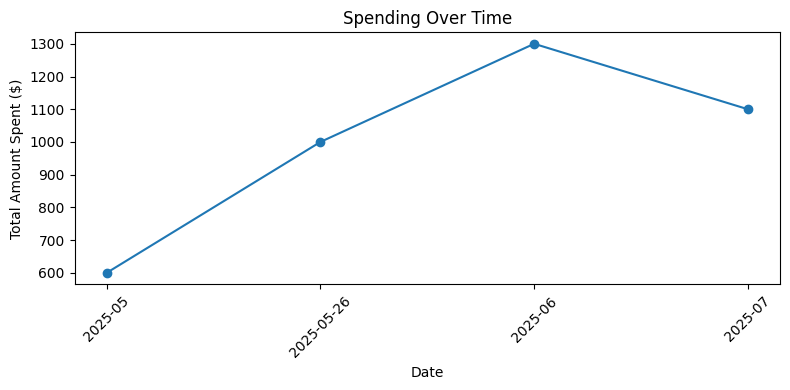


1. Input Income
2. Input Expenses
3. View Summary
4. View Analytics
5. Show Expense Pie Chart
6. Plot Spending Over Time
7. Save and Exit


Choose an option(1-7):  7


Data saved. Goodbye!


In [4]:
import csv
import os
import matplotlib.pyplot as plt
import datetime
FILENAME = "budget_data.csv"

def load_data():
    if not os.path.exists(FILENAME):
        return [], []
    income, expenses = [], []
    with open(FILENAME, mode='r') as file:
        reader = csv.reader(file)
        for row in reader:
            date, category, amount, kind = row
            amount = float(amount)

            if kind == "income":
                income.append((category, amount))
            else:
                expenses.append((date, category, amount))
    return income, expenses

def save_data(income, expenses):
    with open(FILENAME, mode='w', newline='') as file:
        writer = csv.writer(file)
        for category, amount in income:
            writer.writerow(["-", category, amount, "income"])
        for date, category, amount in expenses:
            writer.writerow([date, category, amount, "expense"])

def input_income():
    income = []
    print("\nEnter your sources of income:")
    while True:
        source = input("Source name (or type 'done'): ")
        if source.lower() == "done":
            break
        amount = float(input(f"Amount for {source}: $"))
        income.append((source, amount))
    return income

def input_expenses():
    expenses = []
    default_categories = ["Rent", "Food", "Transport", "Shopping", "Entertainment", "Utlities", "Health", "Education", "Other"]
    print("\nEnter your expenses:")
    print("Suggested categories(you can type your own):")
    print(",".join(default_categories))
    while True:
        category = input("Expense category (or type 'done'): ")
        if category.lower() == "done":
            break
        amount = float(input(f"Amount for {category}: $"))
        date_str = input("Date (month/year) or press Enter for today: ")
        if date_str.strip() == "":
            date_str = str(datetime.date.today())
        expenses.append((date_str, category, amount))
    return expenses

def display_summary(income, expenses):
    total_income = sum(amount for _, amount in income)
    total_expenses = sum(amount for _, amount in expenses)
    balance = total_income - total_expenses

    print("\n--- Budget Summary ---")
    print(f"Total Income:    ${total_income:.2f}")
    print(f"Total Expenses:  ${total_expenses:.2f}")
    print(f"Remaining Balance: ${balance:.2f}")

    print("\n--- Expense Breakdown ---")
    print(f"{'Category':<20}{'Amount':>10}")
    print("-" * 30)
    for date, category, amount in expenses:
        print(f"{category:<20}${amount:>9.2f}")

    return total_income, total_expenses, balance

def display_analytics(income, expenses):
    print("\n--- Budget Analytics ---")
    total_income = sum(amount for _, amount in income)
    total_expenses = sum(amount for _, amount in expenses)
    balance = total_income - total_expenses
    print(f"Total Income:    ${total_income:.2f}")
    print(f"Total Expenses:  ${total_expenses:.2f}")
    print(f"Remaining Balance: ${balance:.2f}")

    if expenses:
        category_totals = {}
        for date, category, amount in expenses:
            category_totals[category] = category_totals.get(category, 0)+ amount
        highest_category = max(category_totals, key = category_totals.get)
        print(f"Top spending Category.: {highest_category} (${category_totals[highest_category]:.2f})")

        avg_expense = total_expenses/len(expenses)
        print(f"Average Expense: ${avg_expense: 2f}")
    else:
        print("No expenses recorded yet, so no analystics to be displyed")
        
def line_plot_spending(expenses):
    if not expenses:
        print("No expenses to plot.")
        return

    daily_totals = {}
    for date, category, amount in expenses:
        daily_totals[date] = daily_totals.get(date, 0) + amount

    # Sort by date
    dates = sorted(daily_totals.keys())
    totals = [daily_totals[d] for d in dates]

    plt.figure(figsize=(8,4))
    plt.plot(dates, totals, marker='o')
    plt.xticks(rotation=45)
    plt.title("Spending Over Time")
    plt.xlabel("Date")
    plt.ylabel("Total Amount Spent ($)")
    plt.tight_layout()
    plt.show()

def plot_pie_chart(expenses):
    if not expenses:
        print("No expenses to plot.")
        return

    category_totals = {}
    for date, category, amount in expenses:
        category_totals[category] = category_totals.get(category, 0) + amount

    labels = list(category_totals.keys())
    amounts = list(category_totals.values())

    plt.figure(figsize=(6,6))
    plt.pie(amounts, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title("Expense Distribution")
    plt.tight_layout()
    plt.show()

def main():
    print("=== Personal Budget Tracker ===")
    income, expenses = load_data()

    while True:
        print("\n1. Input Income")
        print("2. Input Expenses")
        print("3. View Summary")
        print("4. View Analytics")
        print("5. Show Expense Pie Chart")
        print("6. Plot Spending Over Time")
        print("7. Save and Exit")

        choice = input("Choose an option(1-7): ").strip()

        if choice == "1":
            income += input_income()
        elif choice == "2":
            expenses += input_expenses()
        elif choice == "3":
            display_summary(income, expenses)
        elif choice == "4":
            display_analytics(income, expenses)
        elif choice == "5":
            plot_pie_chart(expenses)
        elif choice == "6":
            plot_spending_over_time(expenses)
        elif choice == "7":
            save_data(income, expenses)
            print("Data saved. Goodbye!")
            break

        else:
            print("Invalid choice. Try again.")

if __name__ == "__main__":
    main()